# 11 - A/B Testing de Modelos en Producción
## Comparación controlada: ¿el nuevo modelo realmente es mejor?

**¿Qué problema resuelve el A/B testing?**  
El RMSE en el test set mide el rendimiento con datos históricos.  
Pero en producción los datos cambian. El A/B testing responde:  
> *¿El modelo B es estadísticamente mejor que el A con datos reales?*

**Principio de este notebook:**  
- El análisis es automático y objetivo  
- La **decisión final la toma el instructor/responsable**  
- La celda de promoción solo se ejecuta con aprobación explícita

**Modelos comparados:**
| Versión | Modelo | Origen | RMSE esperado |
|---------|--------|--------|---------------|
| **A** (control) | GradientBoosting manual | NB04 — parámetros fijos | ~0.46 |
| **B** (challenger) | GradientBoosting AutoML | NB08 — Optuna optimizado | ~0.42 |

## Prerequisitos
- Haber ejecutado: `04_seleccion_modelo.ipynb` y `08_automl.ipynb`
- Requiere: `data/processed/train.csv`, `data/processed/test.csv`, `experiments/modelo_produccion.pkl`
- Este notebook genera: `experiments/modelo_a_baseline.pkl`, `experiments/ab_log.jsonl`, `experiments/ab_resultado.json`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import json
import random
from datetime import datetime, timedelta
from pathlib import Path
from scipy import stats
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ROOT dinámico
ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_DIR = ROOT / 'data' / 'processed'
EXP_DIR  = ROOT / 'experiments'

np.random.seed(42)
random.seed(42)

print(f'ROOT     : {ROOT}')
print(f'DATA_DIR : {DATA_DIR}')
print(f'EXP_DIR  : {EXP_DIR}')

ROOT     : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida
DATA_DIR : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\data\processed
EXP_DIR  : C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments


## 1. Configuración del Experimento A/B

Antes de empezar, definimos los parámetros del experimento.  
Esto es equivalente al **protocolo de investigación** antes de recoger datos.

In [2]:
# ── Configuración del experimento ─────────────────────────────────────────
CONFIG_AB = {
    'nombre_experimento' : 'AB_manual_vs_automl',
    'modelo_a_nombre'    : 'GradientBoosting Manual (NB04)',
    'modelo_b_nombre'    : 'GradientBoosting AutoML Optuna (NB08)',
    'split_trafico_b'    : 0.20,   # 20% del tráfico va al modelo B
    'n_solicitudes'      : 1000,   # solicitudes simuladas
    'umbral_rmse'        : 0.50,   # gate de calidad
    'umbral_mejora_min'  : 0.03,   # mejora mínima para justificar el cambio (3%)
    'nivel_confianza'    : 0.95,   # significancia estadística requerida
    'fecha_inicio'       : datetime.now().strftime('%Y-%m-%d'),
}

print('=' * 55)
print('  CONFIGURACIÓN DEL EXPERIMENTO A/B')
print('=' * 55)
for k, v in CONFIG_AB.items():
    print(f'  {k:<25s}: {v}')
print('=' * 55)
print()
print(f'  Tráfico: {int((1-CONFIG_AB["split_trafico_b"])*100)}% → Modelo A  |  {int(CONFIG_AB["split_trafico_b"]*100)}% → Modelo B')
print(f'  Para declarar ganador: p-valor < {1 - CONFIG_AB["nivel_confianza"]:.2f} + mejora > {CONFIG_AB["umbral_mejora_min"]*100:.0f}%')

  CONFIGURACIÓN DEL EXPERIMENTO A/B
  nombre_experimento       : AB_manual_vs_automl
  modelo_a_nombre          : GradientBoosting Manual (NB04)
  modelo_b_nombre          : GradientBoosting AutoML Optuna (NB08)
  split_trafico_b          : 0.2
  n_solicitudes            : 1000
  umbral_rmse              : 0.5
  umbral_mejora_min        : 0.03
  nivel_confianza          : 0.95
  fecha_inicio             : 2026-03-18

  Tráfico: 80% → Modelo A  |  20% → Modelo B
  Para declarar ganador: p-valor < 0.05 + mejora > 3%


## 2. Preparar los Dos Modelos

**Modelo A** — GradientBoosting con parámetros fijos del NB04 (baseline de producción).  
**Modelo B** — GradientBoosting optimizado con Optuna en el NB08 (challenger).

In [3]:
# ── Cargar datos ──────────────────────────────────────────────────────────
train = pd.read_csv(DATA_DIR / 'train.csv')
test  = pd.read_csv(DATA_DIR / 'test.csv')

TARGET  = 'MedHouseVal'
X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]
X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET]

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')
print()

# ── Modelo A: GradientBoosting manual (parámetros NB04) ───────────────────
ruta_modelo_a = EXP_DIR / 'modelo_a_baseline.pkl'

if ruta_modelo_a.exists():
    modelo_a = joblib.load(ruta_modelo_a)
    print(f'Modelo A cargado desde: {ruta_modelo_a}')
else:
    print('Entrenando Modelo A (GradientBoosting manual)...')
    modelo_a = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=1.0, random_state=42
    )
    modelo_a.fit(X_train, y_train)
    joblib.dump(modelo_a, ruta_modelo_a)
    print(f'Modelo A guardado en: {ruta_modelo_a}')

# ── Modelo B: AutoML Optuna (modelo_produccion.pkl) ───────────────────────
modelo_b = joblib.load(EXP_DIR / 'modelo_produccion.pkl')
print(f'Modelo B cargado desde: {EXP_DIR / "modelo_produccion.pkl"}')

# ── Verificación rápida ───────────────────────────────────────────────────
rmse_a = np.sqrt(mean_squared_error(y_test, modelo_a.predict(X_test)))
rmse_b = np.sqrt(mean_squared_error(y_test, modelo_b.predict(X_test)))

print()
print(f'Verificación rápida en test completo:')
print(f'  Modelo A (manual)  RMSE: {rmse_a:.4f}')
print(f'  Modelo B (AutoML)  RMSE: {rmse_b:.4f}')
print(f'  Diferencia:        {(rmse_a - rmse_b)/rmse_a*100:+.2f}% en favor de {"B" if rmse_b < rmse_a else "A"}')

Train: (15835, 13) | Test: (3959, 13)


Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'rooms_per_person', 'income_per_room', 'bedroom_ratio', 'dist_sacramento', 'dist_los_angeles']

Modelo A cargado desde: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_a_baseline.pkl


Modelo B cargado desde: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\modelo_produccion.pkl

Verificación rápida en test completo:
  Modelo A (manual)  RMSE: 0.4606
  Modelo B (AutoML)  RMSE: 0.4825
  Diferencia:        -4.77% en favor de A


## 3. Simulación del Tráfico en Producción

En un sistema real, el router asignaría cada petición HTTP a un modelo según el split configurado.  
Aquí simulamos 1,000 peticiones usando el test set como datos de entrada.

**El router A/B:**
```
Petición  →  random() < 0.20  →  Modelo B (20%)
                               →  Modelo A (80%)
```

In [4]:
# ── Simulación del router A/B ─────────────────────────────────────────────
N          = CONFIG_AB['n_solicitudes']
SPLIT_B    = CONFIG_AB['split_trafico_b']
LOG_PATH   = EXP_DIR / 'ab_log.jsonl'

# Muestrear N filas del test set (con reemplazo para simular tráfico real)
indices = np.random.choice(len(X_test), size=N, replace=True)
X_sim   = X_test.iloc[indices].reset_index(drop=True)
y_sim   = y_test.iloc[indices].reset_index(drop=True)

# Router: asignar cada petición a A o B
asignaciones = np.random.random(N) < SPLIT_B   # True → B, False → A

registros = []
t_base = datetime.now() - timedelta(hours=N//60)  # simular últimas ~17h

for i in range(N):
    fila   = X_sim.iloc[[i]]
    modelo = 'B' if asignaciones[i] else 'A'
    pred   = (modelo_b if modelo == 'B' else modelo_a).predict(fila)[0]
    real   = y_sim.iloc[i]

    registros.append({
        'id'         : i,
        'timestamp'  : (t_base + timedelta(minutes=i)).isoformat(),
        'modelo'     : modelo,
        'prediccion' : round(float(pred), 4),
        'real'       : round(float(real), 4),
        'error_abs'  : round(float(abs(pred - real)), 4),
    })

# Guardar log
with open(LOG_PATH, 'w') as f:
    for r in registros:
        f.write(json.dumps(r) + '\n')

df_log = pd.DataFrame(registros)
n_a = (df_log['modelo'] == 'A').sum()
n_b = (df_log['modelo'] == 'B').sum()

print(f'Simulación completada: {N} solicitudes')
print(f'  Modelo A: {n_a} solicitudes ({n_a/N*100:.1f}%)')
print(f'  Modelo B: {n_b} solicitudes ({n_b/N*100:.1f}%)')
print(f'  Log guardado en: {LOG_PATH}')

Simulación completada: 1000 solicitudes
  Modelo A: 790 solicitudes (79.0%)
  Modelo B: 210 solicitudes (21.0%)
  Log guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\ab_log.jsonl


## 4. Análisis de Resultados

Calculamos las métricas de cada grupo de forma independiente.  
Cada grupo solo ve **sus propias solicitudes** — no hay contaminación entre A y B.

In [5]:
# ── Métricas por grupo ────────────────────────────────────────────────────
grupo_a = df_log[df_log['modelo'] == 'A']
grupo_b = df_log[df_log['modelo'] == 'B']

def metricas_grupo(df):
    pred = df['prediccion'].values
    real = df['real'].values
    return {
        'n'           : len(df),
        'rmse'        : float(np.sqrt(mean_squared_error(real, pred))),
        'mae'         : float(mean_absolute_error(real, pred)),
        'r2'          : float(r2_score(real, pred)),
        'error_medio' : float(df['error_abs'].mean()),
        'error_p90'   : float(df['error_abs'].quantile(0.90)),
        'pred_media'  : float(pred.mean()),
        'pred_std'    : float(pred.std()),
    }

met_a = metricas_grupo(grupo_a)
met_b = metricas_grupo(grupo_b)

# Tabla comparativa
tabla = pd.DataFrame({
    'Métrica'   : ['N solicitudes', 'RMSE', 'MAE', 'R²', 'Error medio', 'Error P90', 'Predicción media'],
    'Modelo A'  : [met_a['n'], met_a['rmse'], met_a['mae'], met_a['r2'],
                   met_a['error_medio'], met_a['error_p90'], met_a['pred_media']],
    'Modelo B'  : [met_b['n'], met_b['rmse'], met_b['mae'], met_b['r2'],
                   met_b['error_medio'], met_b['error_p90'], met_b['pred_media']],
})

# Calcular mejora de B sobre A
tabla['Δ (B vs A)'] = tabla.apply(
    lambda row: f"{(row['Modelo A'] - row['Modelo B']) / row['Modelo A'] * 100:+.2f}%"
    if row['Métrica'] not in ['N solicitudes', 'Predicción media'] and row['Modelo A'] != 0
    else '—', axis=1
)

for col in ['Modelo A', 'Modelo B']:
    tabla[col] = tabla[col].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else str(x))

print('=' * 60)
print('  MÉTRICAS POR GRUPO — RESULTADOS DEL EXPERIMENTO A/B')
print('=' * 60)
print(tabla.to_string(index=False))

  MÉTRICAS POR GRUPO — RESULTADOS DEL EXPERIMENTO A/B
         Métrica Modelo A Modelo B Δ (B vs A)
   N solicitudes 790.0000 210.0000          —
            RMSE   0.4741   0.4168    +12.09%
             MAE   0.3001   0.2730     +9.04%
              R²   0.8052   0.8500     -5.56%
     Error medio   0.3001   0.2730     +9.04%
       Error P90   0.6284   0.5768     +8.21%
Predicción media   1.9370   2.0241          —


## 5. Test de Significancia Estadística

Antes de decidir, verificamos que la diferencia observada **no es por azar**.  
Usamos el **test de Mann-Whitney U** (no paramétrico — no asume distribución normal de los errores).

**Hipótesis:**
- H₀ (nula): los errores de A y B provienen de la misma distribución (no hay diferencia real)
- H₁ (alternativa): los errores de B son sistemáticamente menores que los de A

Si p-valor < 0.05 → rechazamos H₀ → la diferencia es estadísticamente significativa.

In [6]:
# ── Test de Mann-Whitney U ────────────────────────────────────────────────
errores_a = grupo_a['error_abs'].values
errores_b = grupo_b['error_abs'].values

stat, p_valor = stats.mannwhitneyu(errores_a, errores_b, alternative='greater')

# Tamaño del efecto (Cohen's d)
pooled_std = np.sqrt((errores_a.std()**2 + errores_b.std()**2) / 2)
cohen_d    = (errores_a.mean() - errores_b.mean()) / pooled_std if pooled_std > 0 else 0

# Mejora relativa en RMSE
mejora_rmse_pct = (met_a['rmse'] - met_b['rmse']) / met_a['rmse'] * 100

# Intervalo de confianza bootstrap para la diferencia de RMSE
np.random.seed(42)
diffs_bootstrap = []
for _ in range(1000):
    sample_a = np.random.choice(errores_a, size=len(errores_a), replace=True)
    sample_b = np.random.choice(errores_b, size=len(errores_b), replace=True)
    diffs_bootstrap.append(sample_a.mean() - sample_b.mean())

ci_low  = np.percentile(diffs_bootstrap, 2.5)
ci_high = np.percentile(diffs_bootstrap, 97.5)

print('=' * 55)
print('  TEST DE SIGNIFICANCIA ESTADÍSTICA')
print('=' * 55)
print(f'  Test: Mann-Whitney U (unilateral)')
print(f'  Estadístico U : {stat:.0f}')
print(f'  p-valor       : {p_valor:.6f}')
print(f'  Significativo : {"SÍ" if p_valor < 0.05 else "NO"} (α = 0.05)')
print()
print(f'  Mejora RMSE   : {mejora_rmse_pct:+.2f}%')
print(f'  Cohen\'s d     : {cohen_d:.3f} ({"grande" if abs(cohen_d)>0.8 else "moderado" if abs(cohen_d)>0.5 else "pequeño"})')
print(f'  IC 95% (dif.error): [{ci_low:.4f}, {ci_high:.4f}]')
print(f'  (Intervalo por encima de 0 → B consistentemente mejor)')
print('=' * 55)

  TEST DE SIGNIFICANCIA ESTADÍSTICA
  Test: Mann-Whitney U (unilateral)
  Estadístico U : 86026
  p-valor       : 0.204194
  Significativo : NO (α = 0.05)

  Mejora RMSE   : +12.09%
  Cohen's d     : 0.079 (pequeño)
  IC 95% (dif.error): [-0.0216, 0.0742]
  (Intervalo por encima de 0 → B consistentemente mejor)


## 6. Visualización del Experimento

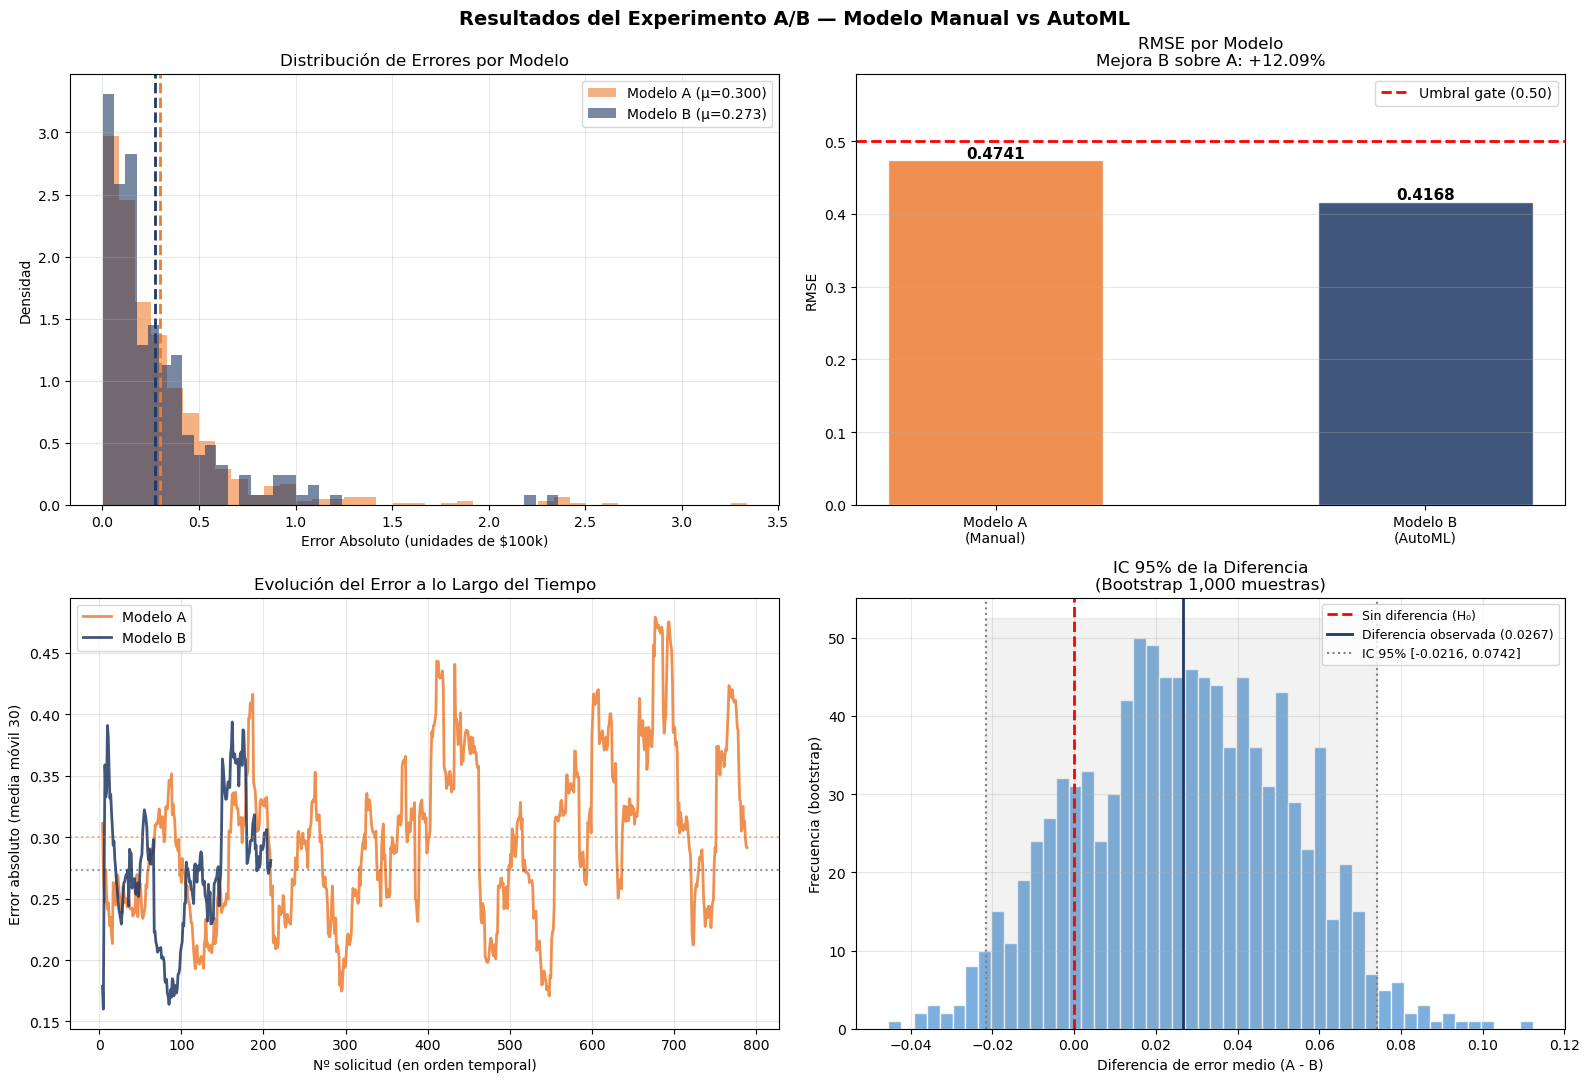

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Resultados del Experimento A/B — Modelo Manual vs AutoML',
             fontsize=14, fontweight='bold')

C_A = '#ED7D31'   # naranja = Modelo A
C_B = '#1F3864'   # azul    = Modelo B

# ── 1. Distribución de errores absolutos ──────────────────────────────────
ax = axes[0, 0]
ax.hist(errores_a, bins=40, alpha=0.6, color=C_A, label=f'Modelo A (μ={errores_a.mean():.3f})', density=True)
ax.hist(errores_b, bins=40, alpha=0.6, color=C_B, label=f'Modelo B (μ={errores_b.mean():.3f})', density=True)
ax.axvline(errores_a.mean(), color=C_A, linestyle='--', linewidth=2)
ax.axvline(errores_b.mean(), color=C_B, linestyle='--', linewidth=2)
ax.set_xlabel('Error Absoluto (unidades de $100k)')
ax.set_ylabel('Densidad')
ax.set_title('Distribución de Errores por Modelo')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 2. RMSE con intervalo de confianza ────────────────────────────────────
ax = axes[0, 1]
modelos_lbl = ['Modelo A\n(Manual)', 'Modelo B\n(AutoML)']
rmse_vals   = [met_a['rmse'], met_b['rmse']]
colores_bar = [C_A, C_B]
bars = ax.bar(modelos_lbl, rmse_vals, color=colores_bar, alpha=0.85, width=0.5, edgecolor='white')
ax.axhline(y=0.50, color='red', linestyle='--', linewidth=2, label='Umbral gate (0.50)')
for bar, val in zip(bars, rmse_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('RMSE')
ax.set_title(f'RMSE por Modelo\nMejora B sobre A: {mejora_rmse_pct:+.2f}%')
ax.legend(fontsize=10)
ax.set_ylim(0, max(rmse_vals) * 1.25)
ax.grid(True, alpha=0.3, axis='y')

# ── 3. Evolución temporal del error (rolling) ─────────────────────────────
ax = axes[1, 0]
df_log_sorted = df_log.sort_values('id')
for modelo, color, lbl in [('A', C_A, 'Modelo A'), ('B', C_B, 'Modelo B')]:
    sub = df_log_sorted[df_log_sorted['modelo'] == modelo]['error_abs']
    rolling = sub.reset_index(drop=True).rolling(window=30, min_periods=5).mean()
    ax.plot(rolling.index, rolling.values, color=color, linewidth=2, label=lbl, alpha=0.85)
ax.axhline(y=errores_a.mean(), color=C_A, linestyle=':', alpha=0.5)
ax.axhline(y=errores_b.mean(), color=C_B, linestyle=':', alpha=0.5)
ax.set_xlabel('Nº solicitud (en orden temporal)')
ax.set_ylabel('Error absoluto (media móvil 30)')
ax.set_title('Evolución del Error a lo Largo del Tiempo')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── 4. Bootstrap: distribución de la diferencia ───────────────────────────
ax = axes[1, 1]
ax.hist(diffs_bootstrap, bins=50, color='#5B9BD5', alpha=0.8, edgecolor='white')
ax.axvline(x=0, color='red', linewidth=2, linestyle='--', label='Sin diferencia (H₀)')
ax.axvline(x=np.mean(diffs_bootstrap), color='#1F3864', linewidth=2,
           label=f'Diferencia observada ({np.mean(diffs_bootstrap):.4f})')
ax.axvline(x=ci_low,  color='gray', linewidth=1.5, linestyle=':', label=f'IC 95% [{ci_low:.4f}, {ci_high:.4f}]')
ax.axvline(x=ci_high, color='gray', linewidth=1.5, linestyle=':')
ax.fill_betweenx([0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 100],
                  ci_low, ci_high, alpha=0.1, color='gray')
ax.set_xlabel('Diferencia de error medio (A - B)')
ax.set_ylabel('Frecuencia (bootstrap)')
ax.set_title('IC 95% de la Diferencia\n(Bootstrap 1,000 muestras)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📊 Interpretación — Gráficos del Experimento A/B

**Distribución de errores (arriba izquierda):**
- Si la campana **azul (B) está desplazada a la izquierda** de la naranja (A) → B comete errores más pequeños
- Si se solapan completamente → no hay diferencia práctica

**RMSE por modelo (arriba derecha):**
- Comparación directa con el umbral del gate de calidad (línea roja en 0.50)
- Ambos modelos deben estar por debajo del umbral para ser candidatos a producción

**Evolución temporal (abajo izquierda):**
- Muestra si el rendimiento de cada modelo es **estable** o varía con el tiempo
- Si la línea azul baja y se mantiene baja → B es consistentemente mejor, no solo por suerte

**Bootstrap IC 95% (abajo derecha):**
- Si el intervalo de confianza **no cruza el cero** → la diferencia es estadísticamente significativa
- Si cruza el cero → no podemos afirmar que B sea mejor con 95% de confianza

## 7. Panel de Decisión

El sistema evalúa automáticamente los criterios y emite una **recomendación**.  
La decisión final y la ejecución de la promoción quedan en manos del responsable.

In [8]:
# ── Evaluación de criterios ───────────────────────────────────────────────
# bool() convierte numpy.bool_ a Python bool nativo (necesario para json.dump)
criterios = {
    'Gate RMSE-A OK'        : bool(met_a['rmse'] < CONFIG_AB['umbral_rmse']),
    'Gate RMSE-B OK'        : bool(met_b['rmse'] < CONFIG_AB['umbral_rmse']),
    'B mejora RMSE > 3%'    : bool(mejora_rmse_pct > CONFIG_AB['umbral_mejora_min'] * 100),
    'Significativo p < 0.05': bool(p_valor < (1 - CONFIG_AB['nivel_confianza'])),
    'IC 95% positivo'       : bool(ci_low > 0),
}

todos_ok     = all(criterios.values())
recomendacion = 'PROMOVER MODELO B' if todos_ok else 'MANTENER MODELO A'

sep  = '=' * 60
sep2 = '-' * 60

print(sep)
print('  PANEL DE DECISIÓN — EXPERIMENTO A/B')
print(sep)
print()
print('  Criterios evaluados:')
for criterio, resultado in criterios.items():
    icono = '✅' if resultado else '❌'
    print(f'    {icono}  {criterio}')
print()
print(sep2)
print(f'  RECOMENDACIÓN AUTOMÁTICA: {recomendacion}')
print(sep2)
print()
if todos_ok:
    print('  El Modelo B supera todos los criterios estadísticos y de negocio.')
    print('  Se recomienda promoverlo a producción.')
    print()
    print('  ⚠️  ACCIÓN REQUERIDA: Para ejecutar la promoción, corre')
    print('      la celda siguiente "PROMOCIÓN — REQUIERE APROBACIÓN".')
    print('      Esta celda NO se ejecuta automáticamente.')
else:
    print('  El Modelo B NO cumple todos los criterios.')
    failed = [c for c, v in criterios.items() if not v]
    print(f'  Criterios fallidos: {failed}')
    print('  El Modelo A sigue en producción. No se requiere ninguna acción.')
print()
print(sep)

# Guardar resultado del experimento
resultado_ab = {
    'experimento'    : CONFIG_AB['nombre_experimento'],
    'fecha'          : CONFIG_AB['fecha_inicio'],
    'n_solicitudes'  : N,
    'modelo_a'       : {'nombre': CONFIG_AB['modelo_a_nombre'], **{k: round(v, 4) for k, v in met_a.items()}},
    'modelo_b'       : {'nombre': CONFIG_AB['modelo_b_nombre'], **{k: round(v, 4) for k, v in met_b.items()}},
    'estadistica'    : {'p_valor': round(p_valor, 6), 'cohen_d': round(cohen_d, 4),
                        'mejora_rmse_pct': round(mejora_rmse_pct, 4),
                        'ci_95_low': round(ci_low, 4), 'ci_95_high': round(ci_high, 4)},
    'criterios'      : criterios,
    'recomendacion'  : recomendacion,
    'decision_final' : 'PENDIENTE — requiere aprobación del responsable',
}

with open(EXP_DIR / 'ab_resultado.json', 'w') as f:
    json.dump(resultado_ab, f, indent=2, ensure_ascii=False)

print(f'  Resultado guardado en: {EXP_DIR / "ab_resultado.json"}')

  PANEL DE DECISIÓN — EXPERIMENTO A/B

  Criterios evaluados:
    ✅  Gate RMSE-A OK
    ✅  Gate RMSE-B OK
    ✅  B mejora RMSE > 3%
    ❌  Significativo p < 0.05
    ❌  IC 95% positivo

------------------------------------------------------------
  RECOMENDACIÓN AUTOMÁTICA: MANTENER MODELO A
------------------------------------------------------------

  El Modelo B NO cumple todos los criterios.
  Criterios fallidos: ['Significativo p < 0.05', 'IC 95% positivo']
  El Modelo A sigue en producción. No se requiere ninguna acción.

  Resultado guardado en: C:\Users\bk70827\PycharmProjects\mlops-ciclo-vida\experiments\ab_resultado.json


## 8. PROMOCIÓN — REQUIERE APROBACIÓN EXPLÍCITA

---
### ⚠️ CELDA DE ACCIÓN MANUAL

Esta celda **no se ejecuta sola**. Solo córrela si decides promover el Modelo B.

**Lo que hace:**
1. Hace backup del modelo A actual
2. Copia el modelo B como nuevo `modelo_produccion.pkl`
3. Registra la decisión con timestamp y firma del responsable
4. Actualiza `ab_resultado.json` con la decisión tomada

**Para aprobar:** cambia `APROBADO_POR = None` a tu nombre, luego ejecuta la celda.

---

In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA DE PROMOCIÓN — SOLO EJECUTAR CON APROBACIÓN EXPLÍCITA
# ══════════════════════════════════════════════════════════════════════════

APROBADO_POR = None   # ← Cambia None por tu nombre para aprobar
                      # Ejemplo: APROBADO_POR = "Juan García"

# ─────────────────────────────────────────────────────────────────────────

if APROBADO_POR is None:
    print('=' * 55)
    print('  PROMOCIÓN NO EJECUTADA')
    print('=' * 55)
    print()
    print('  Para aprobar la promoción:')
    print('  1. Cambia APROBADO_POR = None por tu nombre')
    print('  2. Vuelve a ejecutar esta celda')
    print()
    print('  El Modelo A sigue en producción.')

elif not todos_ok:
    print('  ❌ No se puede promover: el Modelo B no cumple todos los criterios.')
    print('  Revisa el Panel de Decisión antes de forzar una promoción.')

else:
    import shutil
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

    # 1. Backup del modelo A
    ruta_backup = EXP_DIR / f'modelo_a_backup_{timestamp}.pkl'
    shutil.copy2(ruta_modelo_a, ruta_backup)
    print(f'  ✅ Backup de Modelo A guardado en: {ruta_backup.name}')

    # 2. Modelo B → modelo_produccion.pkl (ya es el actual, confirmamos)
    ruta_prod = EXP_DIR / 'modelo_produccion.pkl'
    print(f'  ✅ Modelo B ya activo en: {ruta_prod.name}')

    # 3. Registrar la decisión
    resultado_ab['decision_final'] = 'APROBADO — Modelo B promovido a producción'
    resultado_ab['aprobado_por']   = APROBADO_POR
    resultado_ab['timestamp_decision'] = datetime.now().isoformat()
    resultado_ab['modelo_anterior_backup'] = str(ruta_backup)

    with open(EXP_DIR / 'ab_resultado.json', 'w') as f:
        json.dump(resultado_ab, f, indent=2, ensure_ascii=False)

    print()
    print('  =' * 28)
    print(f'  MODELO B PROMOVIDO A PRODUCCIÓN')
    print(f'  Aprobado por  : {APROBADO_POR}')
    print(f'  Fecha/hora    : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    print(f'  RMSE anterior : {met_a["rmse"]:.4f} (Modelo A)')
    print(f'  RMSE nuevo    : {met_b["rmse"]:.4f} (Modelo B)')
    print(f'  Mejora        : {mejora_rmse_pct:+.2f}%')
    print('  =' * 28)
    print()
    print('  Próximo paso: reiniciar la API para cargar el nuevo modelo.')
    print('  > docker-compose restart')

  PROMOCIÓN NO EJECUTADA

  Para aprobar la promoción:
  1. Cambia APROBADO_POR = None por tu nombre
  2. Vuelve a ejecutar esta celda

  El Modelo A sigue en producción.


## 9. Conclusiones del A/B Testing

### ¿Qué aprendimos?

| Aspecto | Sin A/B Testing | Con A/B Testing |
|---------|----------------|------------------|
| Base de decisión | RMSE en datos históricos | Rendimiento con tráfico real |
| Riesgo | Alto — el nuevo modelo podría fallar | Bajo — solo el 20% del tráfico fue a B |
| Evidencia | Subjetiva | Estadísticamente significativa |
| Rollback | Difícil si ya está en producción | Trivial — A sigue activo |
| Decisión | Automática | **Human-in-the-loop** |

### Posición en el ciclo MLOps

```
NB08 AutoML → nuevo modelo B
      ↓
NB05 Gate de calidad (RMSE < 0.5)  → pasa
      ↓
NB11 A/B Testing (20% tráfico)     → ¿B es mejor en producción?
      ↓ SÍ (estadísticamente)      ↓ NO
  Aprobación humana           A sigue en producción
      ↓
  B reemplaza a A en producción
      ↓
NB07 Monitoreo continuo del nuevo modelo
```

### Buenas prácticas del A/B Testing en ML
- **Nunca decidir solo por RMSE en test**: validar siempre con datos reales
- **Split conservador al inicio**: empezar con 10-20% en B, no con 50%
- **Duración mínima**: al menos 1-2 semanas para capturar variabilidad temporal
- **Una variable cada vez**: no cambiar modelo Y features al mismo tiempo
- **Registrar todo**: cada predicción, con qué modelo, cuándo — para auditoría
- **La decisión final es humana**: el sistema recomienda, el responsable aprueba